## **1. Clasificadores en datos transcriptómicos**

In [34]:
# ============================================================
# Imports (consolidados)
# ============================================================
import os, sys, socket, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import randint, uniform
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import sklearn
from sklearn.preprocessing import (LabelEncoder, LabelBinarizer,
                                   StandardScaler, MinMaxScaler)
from sklearn.impute import KNNImputer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, cross_val_score,
                                     StratifiedKFold, RepeatedStratifiedKFold)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay,
                             silhouette_score, adjusted_rand_score)
from xgboost import XGBClassifier
import umap

warnings.filterwarnings('ignore')


In [2]:
print("Hostname:", socket.gethostname())
print("User:", os.environ.get("USER"))

Hostname: HAL
User: dlaguna


In [3]:
print(sys.executable)

/home/dlaguna/miniconda3/envs/tcga/bin/python3.10


In [6]:
df = pd.read_csv("Consensus_DEG_signature.tsv", sep="\t")

In [9]:
df.head()

,Subtipo,BRCA_LumA,BRCA_LumA.1,BRCA_LumA.2,BRCA_LumA.3,BRCA_LumA.4,BRCA_LumA.5,BRCA_LumA.6,BRCA_LumA.7,BRCA_LumA.8,...,BRCA_Basal.156,BRCA_Basal.157,BRCA_Basal.158,BRCA_Basal.159,BRCA_Basal.160,BRCA_Basal.161,BRCA_Basal.162,BRCA_Basal.163,BRCA_Basal.164,BRCA_Basal.165
0,IDPaciente,TCGA-A2-A0T6,TCGA-C8-A26Z,TCGA-D8-A1XY,TCGA-AR-A24L,TCGA-A2-A1G0,TCGA-BH-A0HQ,TCGA-AR-A0U3,TCGA-B6-A2IU,TCGA-AO-A03V,...,TCGA-AN-A0XU,TCGA-LL-A5YP,TCGA-B6-A0IJ,TCGA-AC-A7VC,TCGA-AR-A1AJ,TCGA-E2-A14R,TCGA-A2-A0ST,TCGA-D8-A27F,TCGA-EW-A1P4,TCGA-B6-A0X1
1,SLC7A2,5.61242032623821,3.40420830373145,3.97032910990328,5.38696955145318,7.05826670183546,1.97236180701735,6.045228892206,5.38998317843967,4.50854274516769,...,1.28569812595812,0.662205499653617,0.919835834281514,1.8629075857564,1.09017594979021,0.238786859587116,1.66548373255265,0.58014548442338,2.64724542433163,0.751977806587636
2,PDK4,4.46382514178991,1.20989000723404,1.86951611604805,3.0149443921958,6.21307893883334,2.3506386808415,3.3684890006451,4.4030836237973,4.16014572540458,...,1.06412406481895,2.09115819298597,0.557581639729309,2.32460901517973,4.02592355504676,0.619835544497311,2.58594800565658,1.8425766307707,1.39017239630348,1.57700577689281
3,ZMYND10,2.58659662926947,1.52165382826663,1.70216991427997,1.7159812031884,3.37446919339681,3.01178185945991,2.71988435206313,3.68304512977574,2.08722520131978,...,0.34118877247874,0.551491408547495,0.0994972011701899,0.638212885423406,0.277508728144778,1.48424126925153,0.445514838302113,0.226385217270386,0.453649266043291,0.726046456482002
4,SOX8,0.214497867900516,0.114500293165193,0.056860943046751,0.130799110838194,0.244399991245549,0.12234140752612,0.0557509641184532,0.186373777465944,0.282380494638606,...,0.0716253939737696,2.85235846694904,0.0735460609151547,0.218471210743262,0.59617186214146,4.04642121124871,1.74940554564075,2.86827191110476,0.0563060603318765,0.676628488242969


In [10]:
# df.info()

In [11]:
df_samples = df.set_index('Subtipo').T
df_samples.index.name = 'SampleID'
df_samples = df_samples.reset_index()
df_samples['Subtype'] = df_samples['SampleID'].str.extract(r'BRCA_([A-Za-z]+)', expand=False)

print(df_samples.head())
print(df_samples.shape)

Subtipo     SampleID    IDPaciente            SLC7A2              PDK4  \
0          BRCA_LumA  TCGA-A2-A0T6  5.61242032623821  4.46382514178991   
1        BRCA_LumA.1  TCGA-C8-A26Z  3.40420830373145  1.20989000723404   
2        BRCA_LumA.2  TCGA-D8-A1XY  3.97032910990328  1.86951611604805   
3        BRCA_LumA.3  TCGA-AR-A24L  5.38696955145318   3.0149443921958   
4        BRCA_LumA.4  TCGA-A2-A1G0  7.05826670183546  6.21307893883334   

Subtipo           ZMYND10               SOX8            CX3CL1  \
0        2.58659662926947  0.214497867900516  2.02966490132192   
1        1.52165382826663  0.114500293165193  1.49010798328815   
2        1.70216991427997  0.056860943046751  1.91811904395741   
3         1.7159812031884  0.130799110838194  1.98582827828741   
4        3.37446919339681  0.244399991245549  4.86261504287646   

Subtipo              PROM1             TFAP2B              NFIX  ...  \
0         4.27727065965564   5.94427516059799  4.24023036051211  ...   
1        0.272

**Codificar Etiquetas de Subtipo**

Convertir las etiquetas de subtipo categóricas (LumA, LumB, Basal) a un formato numérico usando LabelEncoder, ya que los modelos de Machine Learning requieren entradas numéricas para la variable objetivo.

In [12]:
subtype_mapping = {'LumA': 0, 'LumB': 1, 'Basal': 2}
df_samples['Subtype_Encoded'] = df_samples['Subtype'].map(subtype_mapping)

print(df_samples[['SampleID', 'Subtype', 'Subtype_Encoded']].head())
print("\nUnique Subtypes and their Encoded Values:")
print(df_samples[['Subtype', 'Subtype_Encoded']].drop_duplicates().sort_values(by='Subtype_Encoded'))

Subtipo     SampleID Subtype  Subtype_Encoded
0          BRCA_LumA    LumA                0
1        BRCA_LumA.1    LumA                0
2        BRCA_LumA.2    LumA                0
3        BRCA_LumA.3    LumA                0
4        BRCA_LumA.4    LumA                0

Unique Subtypes and their Encoded Values:
Subtipo Subtype  Subtype_Encoded
0          LumA                0
191        LumB                1
386       Basal                2


### **2. Dividir Datos en Entrenamiento y Prueba**

Dividir los datos transformados en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo de clasificación de manera imparcial.


In [13]:
X = df_samples.drop(columns=['SampleID', 'IDPaciente', 'Subtype', 'Subtype_Encoded'])
y = df_samples['Subtype_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (386, 604)
Shape of X_test: (166, 604)
Shape of y_train: (386,)
Shape of y_test: (166,)


In [15]:
df_samples['Subtype'].value_counts()

Subtype
LumB     195
LumA     191
Basal    166
Name: count, dtype: int64

In [16]:
# =============================================
# GUARDAR PATIENT IDs DEL SPLIT
# =============================================

# Los índices de X_train y X_test apuntan a filas de df_samples
train_patient_ids = df_samples.loc[X_train.index, 'IDPaciente'].str[:12]
test_patient_ids  = df_samples.loc[X_test.index,  'IDPaciente'].str[:12]
train_subtypes    = df_samples.loc[X_train.index, 'Subtype']
test_subtypes     = df_samples.loc[X_test.index,  'Subtype']

# Crear dataframe con el split
df_train_ids = pd.DataFrame({
    'patient_id': train_patient_ids.values,
    'Subtype':    train_subtypes.values,
    'split':      'train'
})

df_test_ids = pd.DataFrame({
    'patient_id': test_patient_ids.values,
    'Subtype':    test_subtypes.values,
    'split':      'test'
})

df_split = pd.concat([df_train_ids, df_test_ids], ignore_index=True)

print("Distribución split:")
print(df_split['split'].value_counts())
print("\nDistribución subtipos train:")
print(df_split[df_split['split']=='train']['Subtype'].value_counts())
print("\nDistribución subtipos test:")
print(df_split[df_split['split']=='test']['Subtype'].value_counts())
print("\nEjemplos:")
print(df_split.head(13))

# Guardar
#df_split.to_csv('split_transcriptomica_604.csv', index=False)
print("\nArchivo guardado: split_transcriptomica_604.csv")

Distribución split:
split
train    386
test     166
Name: count, dtype: int64

Distribución subtipos train:
Subtype
LumB     136
LumA     134
Basal    116
Name: count, dtype: int64

Distribución subtipos test:
Subtype
LumB     59
LumA     57
Basal    50
Name: count, dtype: int64

Ejemplos:
      patient_id Subtype  split
0   TCGA-BH-A18V   Basal  train
1   TCGA-AR-A0TY    LumB  train
2   TCGA-BH-A18L    LumB  train
3   TCGA-D8-A1Y2    LumB  train
4   TCGA-E2-A1B6   Basal  train
5   TCGA-C8-A26W    LumB  train
6   TCGA-D8-A1XR    LumB  train
7   TCGA-C8-A12U    LumB  train
8   TCGA-EW-A1J1    LumA  train
9   TCGA-BH-A18G   Basal  train
10  TCGA-A1-A0SH    LumA  train
11  TCGA-A1-A0SJ    LumA  train
12  TCGA-D8-A27W    LumB  train

Archivo guardado: split_transcriptomica_604.csv


### **3. Modelos supervisados**

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)          # para tunear (GridSearch/RandomizedSearch)
cv_report = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)  # para el reporte final

#### **MODELO 1: KNN**

In [18]:
# Modelo de K-Vecinos más cercanos
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 31),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['minkowski', 'cosine'],
    'knn__p': [1, 2, 3]
}

grid_clf = GridSearchCV(knn_pipeline,
                        param_grid=param_grid,
                        verbose=1,
                        return_train_score=True,
                        cv=cv,
                        scoring='accuracy')
grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 360 candidates, totalling 1080 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['minkowski', 'cosine'], 'knn__n_neighbors': range(1, 31), 'knn__p': [1, 2, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [19]:
knn_best = grid_clf.best_estimator_
knn_best

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,6
,weights,'distance'
,algorithm,'auto'
,leaf_size,30


In [20]:
print("Mejores hiperparámetros encontrados por GridSearchCV:")
print(grid_clf.best_params_)

Mejores hiperparámetros encontrados por GridSearchCV:
{'knn__metric': 'minkowski', 'knn__n_neighbors': 6, 'knn__p': 3, 'knn__weights': 'distance'}


In [21]:
# Puntaje de la mejor combinación de parámetros.
print(f"Puntaje de la mejor combinación de parámetros: {grid_clf.best_score_:.4f}")

Puntaje de la mejor combinación de parámetros: 0.9146


In [22]:
# Predicciones
y_pred = knn_best.predict(X_test) # Usar X_test_knn
# Para multiclass ROC AUC, necesitamos las probabilidades para todas las clases
y_proba = knn_best.predict_proba(X_test) # Usar X_test_knn

# Métricas - Ajustar 'average' para problemas multiclass
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Para roc_auc_score multiclass, se requiere multi_class y average
# Usamos 'ovr' (one-vs-rest) y 'weighted' average para manejar múltiples clases
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

# Reporte y matriz de confusión
print("Clasification Report:\n", classification_report(y_test, y_pred))

train_accuracy_knn = knn_best.score(X_train, y_train)

test_accuracy_knn = accuracy_score(y_test, y_pred)

print(f"Precisión en el conjunto de entrenamiento (KNN): {train_accuracy_knn:.4f}")
print(f"Precisión en el conjunto de prueba (KNN): {test_accuracy_knn:.4f}")

Clasification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79        57
           1       0.81      0.78      0.79        59
           2       0.98      0.98      0.98        50

    accuracy                           0.85       166
   macro avg       0.86      0.86      0.86       166
weighted avg       0.85      0.85      0.85       166

Precisión en el conjunto de entrenamiento (KNN): 1.0000
Precisión en el conjunto de prueba (KNN): 0.8494


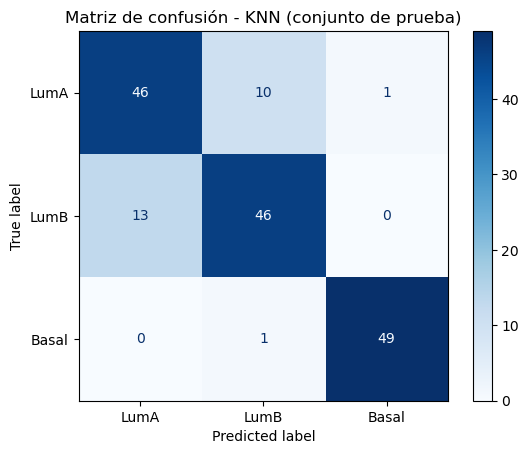

In [39]:
# Calcular matriz de confusión
label_names = ["LumA", "LumB", "Basal"]   # 0, 1, 2
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - KNN (conjunto de prueba)")
plt.show()

#### **MODELO 2: Random Forest Classifier**

Entrenar un modelo Random Forest Classifier utilizando los datos de entrenamiento para predecir el subtipo de la muestra.

In [24]:
# --- 2. Definir el modelo base ---
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# --- 3. ESPACIO DE HIPERPARÁMETROS PARA RANDOM SEARCH ---
param_dist = {
    "n_estimators": [100, 200, 300, 500],          # árboles
    "max_depth": [None, 30, 40, 50],                 # profundidad
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.02, 0.05, 0.1, 0.15, 0.18],         # entre 2% y 18%
    "criterion": ["gini", "entropy"]
}

# --- 4. RANDOMIZED SEARCH ---
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,                     # número de configuraciones probadas
    scoring="accuracy",
    cv=cv,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

# --- 5. Ajustar la búsqueda ---
random_search.fit(X_train, y_train)

# --- 6. Ver los mejores hiperparámetros ---
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# --- 7. Evaluación final ---
best_rf = random_search.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_test_pred  = best_rf.predict(X_test)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred))   # ← y_test_pred, no y_pred

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)
print(f"Precisión en el conjunto de entrenamiento: {train_accuracy:.4f}")
print(f"Precisión en el conjunto de prueba: {test_accuracy:.4f}")

Mejores hiperparámetros encontrados:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.15, 'max_depth': 30, 'criterion': 'entropy'}

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        57
           1       0.87      0.88      0.87        59
           2       0.98      1.00      0.99        50

    accuracy                           0.90       166
   macro avg       0.91      0.91      0.91       166
weighted avg       0.90      0.90      0.90       166

Precisión en el conjunto de entrenamiento: 1.0000
Precisión en el conjunto de prueba: 0.9036


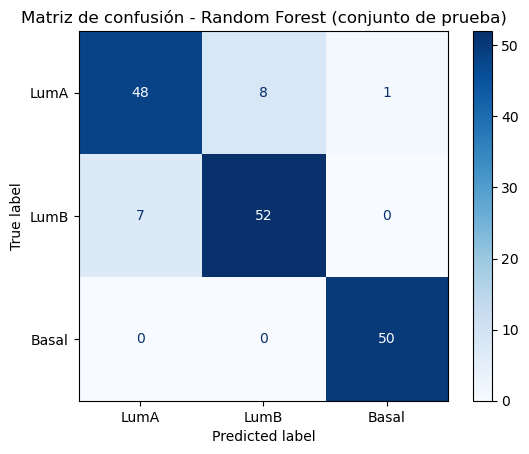

In [40]:
# Predicciones en test
y_test_pred = best_rf.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Random Forest (conjunto de prueba)")
plt.show()

#### **MODELO 3: Logistic Regression  model**

In [26]:
# Create a pipeline for StandardScaler and LogisticRegression
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(random_state=42))
])

# Define the parameter grid for GridSearchCV
# Note: Some combinations of penalty, solver, and multi_class are not compatible.
# GridSearchCV will skip invalid combinations automatically.
param_grid = [
    {
        'logisticregression__C': [0.001, 0.01, 0.1, 1],
        'logisticregression__penalty': ['l1', 'l2'],
        'logisticregression__solver': ['liblinear'],
        'logisticregression__multi_class': ['ovr']
    },
    {
        'logisticregression__C': [0.001, 0.01, 0.1, 1],
        'logisticregression__penalty': ['l2'], # lbfgs only supports l2 and none
        'logisticregression__solver': ['lbfgs', 'newton-cg'], # Common solvers for l2
        'logisticregression__multi_class': ['ovr', 'multinomial']
    },
    {
        'logisticregression__C': [0.001, 0.01, 0.1, 1],
        'logisticregression__penalty': ['l1', 'l2'], # saga supports l1 and l2
        'logisticregression__solver': ['saga'],
        'logisticregression__multi_class': ['ovr', 'multinomial']
    }
]

# Initialize GridSearchCV
grid_search_log_reg = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_log_reg.fit(X_train, y_train)

# Print the best hyperparameters and best score
print("Best hyperparameters found: ", grid_search_log_reg.best_params_)
print("Best cross-validation accuracy: ", grid_search_log_reg.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best hyperparameters found:  {'logisticregression__C': 0.1, 'logisticregression__multi_class': 'multinomial', 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'saga'}
Best cross-validation accuracy:  0.9300306847545219


In [27]:
# 1. # Mejor modelo
best_log_reg_model = grid_search_log_reg.best_estimator_

# 2. Realiza predicciones sobre el conjunto de prueba X_test
y_pred_log_reg = best_log_reg_model.predict(X_test)

# 3. Calcula la precisión del modelo
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print("Precisión en el conjunto de entrenamiento: ", grid_search_log_reg.best_score_)
print(f"Precisión en el conjunto de prueba: {accuracy_log_reg:.4f}")

# 4. Genera un informe de clasificación
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
print("\nReporte de clasificación (Logistic Regression model):\n", class_report_log_reg)

Precisión en el conjunto de entrenamiento:  0.9300306847545219
Precisión en el conjunto de prueba: 0.9458

Reporte de clasificación (Logistic Regression model):
               precision    recall  f1-score   support

           0       0.96      0.88      0.92        57
           1       0.90      0.97      0.93        59
           2       0.98      1.00      0.99        50

    accuracy                           0.95       166
   macro avg       0.95      0.95      0.95       166
weighted avg       0.95      0.95      0.95       166



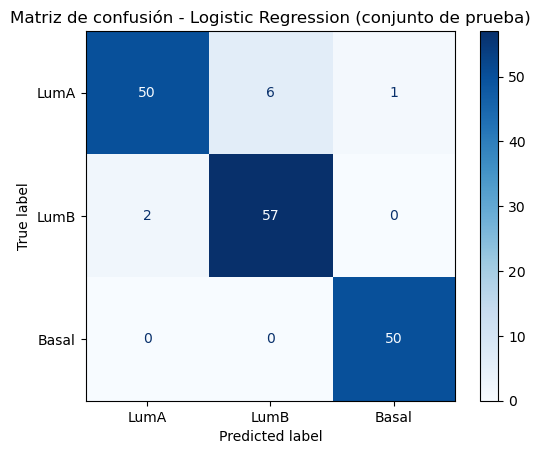

In [41]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log_reg, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Logistic Regression (conjunto de prueba)")
plt.show()

#### **MODELO 4: Modelo XGBoost**

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best params (XGB): {'clf__colsample_bytree': np.float64(0.5364192989498333), 'clf__learning_rate': np.float64(0.06951547789558385), 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 515, 'clf__reg_alpha': np.float64(0.5632882178455393), 'clf__reg_lambda': np.float64(1.2708330050798322), 'clf__subsample': np.float64(0.6047898756660642), 'sel__k': 200}
Best CV (f1_macro): 0.936

Precisión en entrenamiento (XGBoost): 1.0
Precisión en prueba (XGBoost): 0.91


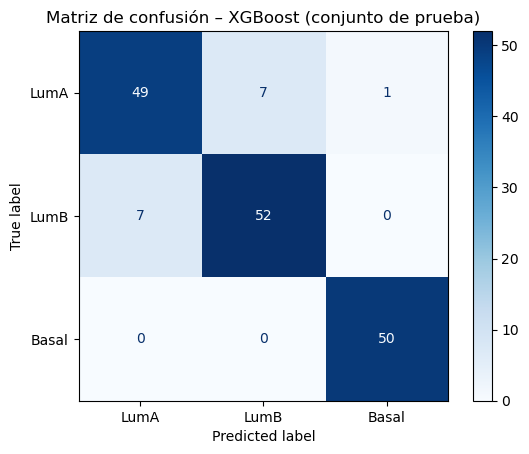

In [29]:
# ------------------------------------------------------------------
# 1) Pesos por clase (y ya viene codificado 0/1/2 = Subtype_Encoded)
# ------------------------------------------------------------------
label_map = {0: "LumA", 1: "LumB", 2: "Basal"}   # mismo mapeo en todo el pipeline

cls_counts    = pd.Series(y_train).value_counts()
class_weight  = (cls_counts.sum() / (len(cls_counts) * cls_counts)).to_dict()
sample_weight = pd.Series(y_train).map(class_weight).values

# ------------------------------------------------------------------
# 2) Pipeline: SelectKBest -> XGBClassifier
# ------------------------------------------------------------------
pipe_xgb = Pipeline(steps=[
    ("sel", SelectKBest(score_func=f_classif)),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train)),
        tree_method="hist",
        n_jobs=-1,
        eval_metric="mlogloss",
        random_state=42
    ))
])

# ------------------------------------------------------------------
# 3) Búsqueda de hiperparámetros (RandomizedSearchCV)
# ------------------------------------------------------------------
param_dist = {
    "sel__k":               [100, 200, 400, "all"],
    "clf__n_estimators":    randint(200, 600),
    "clf__max_depth":       randint(3, 8),
    "clf__learning_rate":   uniform(0.05, 0.3),
    "clf__subsample":       uniform(0.6, 0.3),
    "clf__colsample_bytree":uniform(0.4, 0.8),
    "clf__min_child_weight":randint(1, 5),
    "clf__reg_lambda":      uniform(0.5, 2.0),
    "clf__reg_alpha":       uniform(0.0, 1.0),
}

rs_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist,
    n_iter=60,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs_xgb.fit(X_train, y_train, clf__sample_weight=sample_weight)
print("Best params (XGB):", rs_xgb.best_params_)
print("Best CV (f1_macro):", round(rs_xgb.best_score_, 3))
best_xgb = rs_xgb.best_estimator_

# -------------------
# TRAIN
# -------------------
y_train_pred = best_xgb.predict(X_train)
print("\nPrecisión en entrenamiento (XGBoost):", round(accuracy_score(y_train, y_train_pred), 3))

# -------------------
# TEST
# -------------------
y_test_pred = best_xgb.predict(X_test)
print("Precisión en prueba (XGBoost):", round(accuracy_score(y_test, y_test_pred), 3))

# -------------------
# Matriz de confusión
# -------------------
cm_xgb = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=[label_map[i] for i in sorted(label_map)]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión – XGBoost (conjunto de prueba)")
plt.show()

In [30]:
# TEST
label_map = {0: "LumA", 1: "LumB", 2: "Basal"}
y_test_pred = best_xgb.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("Precisión en el conjunto de prueba (XGBoost):", round(test_acc, 3))

print("\nReporte de clasificación - TEST (XGBoost):\n")
print(classification_report(
    y_test, y_test_pred,
    labels=[0, 1, 2],
    target_names=[label_map[i] for i in [0, 1, 2]]
))

Precisión en el conjunto de prueba (XGBoost): 0.91

Reporte de clasificación - TEST (XGBoost):

              precision    recall  f1-score   support

        LumA       0.88      0.86      0.87        57
        LumB       0.88      0.88      0.88        59
       Basal       0.98      1.00      0.99        50

    accuracy                           0.91       166
   macro avg       0.91      0.91      0.91       166
weighted avg       0.91      0.91      0.91       166



#### **MODELO 5: Modelo Máquinas de Vectores de Soporte (SVM)**

In [31]:
# Create a pipeline for StandardScaler and SVC
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

# Define the parameter grid for GridSearchCV
param_grid_svm = {
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__kernel': ['poly', 'rbf'],
    'svc__gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
    'svc__degree': [2,3,4],
     'svc__coef0': [0.0, 0.1, 1.0],  # for poly
}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_svm.fit(X_train, y_train)

# Print the best hyperparameters and best score
print("Best hyperparameters found: ", grid_search_svm.best_params_)
print("Best cross-validation accuracy: ", grid_search_svm.best_score_)


# Get the best SVM estimator
best_svm_model = grid_search_svm.best_estimator_

# Make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test)

# Predicciones en entrenamiento
y_train_pred_svm = best_svm_model.predict(X_train)
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)

print(f"Precisión en el conjunto de entrenamiento (SVM): {train_accuracy_svm:.4f}")

# Predicciones en test
y_test_pred_svm = best_svm_model.predict(X_test)

test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"Precisión en el conjunto de prueba (SVM): {test_accuracy_svm:.4f}")

# Generate classification report
class_report_svm = classification_report(y_test, y_pred_svm)
print("\nReporte de clasificación (SVM model):\n", class_report_svm)

Fitting 3 folds for each of 540 candidates, totalling 1620 fits
Best hyperparameters found:  {'svc__C': 10, 'svc__coef0': 1.0, 'svc__degree': 4, 'svc__gamma': 0.0001, 'svc__kernel': 'poly'}
Best cross-validation accuracy:  0.9274870801033591
Precisión en el conjunto de entrenamiento (SVM): 0.9896
Precisión en el conjunto de prueba (SVM): 0.9036

Reporte de clasificación (SVM model):
               precision    recall  f1-score   support

           0       0.88      0.86      0.87        57
           1       0.87      0.88      0.87        59
           2       0.98      0.98      0.98        50

    accuracy                           0.90       166
   macro avg       0.91      0.91      0.91       166
weighted avg       0.90      0.90      0.90       166



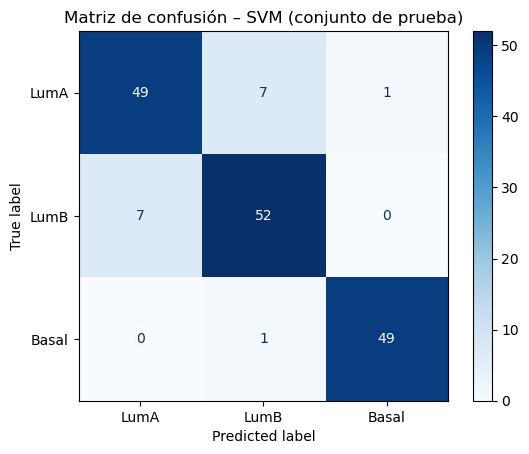

In [42]:
cm_svm = confusion_matrix(y_test, y_test_pred_svm, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=label_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión – SVM (conjunto de prueba)")
plt.show()

In [36]:
modelos = {"KNN": knn_best, "Random Forest": best_rf,
           "Logistic Regression": best_log_reg_model,
           "XGBoost": best_xgb, "SVM": best_svm_model}

filas = []
for nombre, modelo in modelos.items():
    s = cross_val_score(modelo, X, y, cv=cv_report, scoring="f1_macro", n_jobs=-1)
    filas.append({"Modelo": nombre,
                  "F1_macro_media": round(s.mean(), 3),
                  "F1_macro_std":   round(s.std(), 3)})

tabla_cv = pd.DataFrame(filas).set_index("Modelo").sort_values("F1_macro_media", ascending=False)
print(tabla_cv)

                     F1_macro_media  F1_macro_std
Modelo                                           
XGBoost                       0.932         0.019
Logistic Regression           0.931         0.019
Random Forest                 0.924         0.026
SVM                           0.914         0.027
KNN                           0.885         0.030


In [38]:
from scipy.stats import wilcoxon

modelos = {"KNN": knn_best, "Random Forest": best_rf,
           "Logistic Regression": best_log_reg_model,
           "XGBoost": best_xgb, "SVM": best_svm_model}

# Métricas robustas (macro, adecuadas para clases desbalanceadas)
scoring = {
    "F1_macro":        "f1_macro",
    "Balanced_acc":    "balanced_accuracy",
    "Precision_macro": "precision_macro",
    "Recall_macro":    "recall_macro",
}

filas, f1_folds = [], {}
for nombre, modelo in modelos.items():
    res = cross_validate(modelo, X, y, cv=cv_report, scoring=scoring, n_jobs=-1)
    f1_folds[nombre] = res["test_F1_macro"]          # se guarda para el test estadístico
    fila = {"Modelo": nombre}
    for m in scoring:
        fila[m] = f"{res['test_'+m].mean():.3f} ± {res['test_'+m].std():.3f}"
    filas.append(fila)

tabla = pd.DataFrame(filas).set_index("Modelo").sort_values("F1_macro", ascending=False)
print(tabla.to_string())

# --- Test estadístico entre los dos mejores modelos ---
top2 = tabla.index[:2].tolist()
stat, p = wilcoxon(f1_folds[top2[0]], f1_folds[top2[1]])
print(f"\nWilcoxon {top2[0]} vs {top2[1]} (F1-macro por fold): p = {p:.3f}")
print("Diferencia significativa" if p < 0.05 else
      "Sin diferencia significativa -> rinden equivalente")

                          F1_macro   Balanced_acc Precision_macro   Recall_macro
Modelo                                                                          
XGBoost              0.932 ± 0.019  0.932 ± 0.020   0.934 ± 0.019  0.932 ± 0.020
Logistic Regression  0.931 ± 0.019  0.930 ± 0.020   0.933 ± 0.018  0.930 ± 0.020
Random Forest        0.924 ± 0.026  0.924 ± 0.025   0.926 ± 0.025  0.924 ± 0.025
SVM                  0.914 ± 0.027  0.914 ± 0.027   0.916 ± 0.027  0.914 ± 0.027
KNN                  0.885 ± 0.030  0.886 ± 0.030   0.890 ± 0.029  0.886 ± 0.030

Wilcoxon XGBoost vs Logistic Regression (F1-macro por fold): p = 0.706
Sin diferencia significativa -> rinden equivalente


### **VALIDACIÓN EXTERNA: Cohorte INC Bogotá**

Índice (primeras filas): ['Response', 'slide_ID', 'A2ML1', 'AARD']
Shape df_inc (muestras x genes): (23, 601)
Primeros genes: ['A2ML1', 'AARD', 'ABAT']

Muestras INC: 23 | Genes alineados: 604
Genes faltantes (9): ['SPOCK2', 'NEURL1', 'ADAMDEC1', 'FGFBP1', 'LY6D', 'TAP1', 'CST5', 'C6orf15', 'OR2I1P']


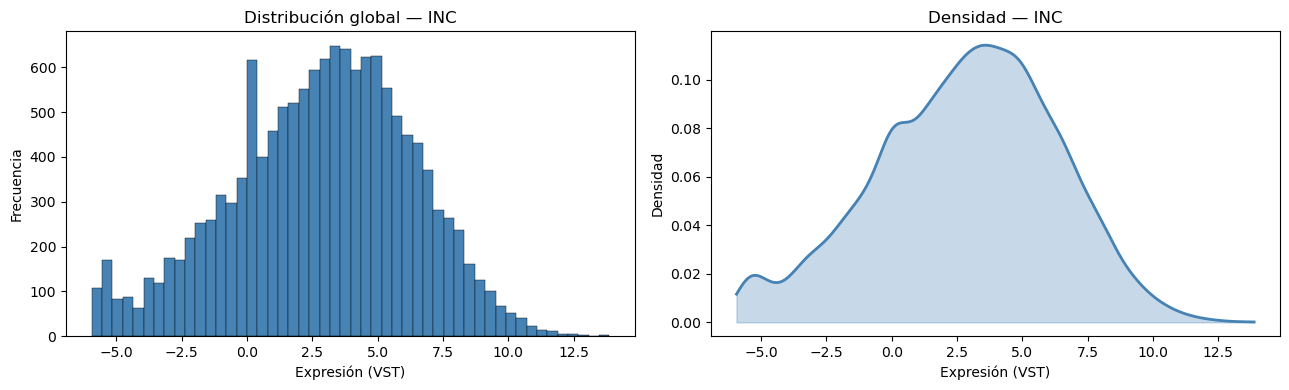

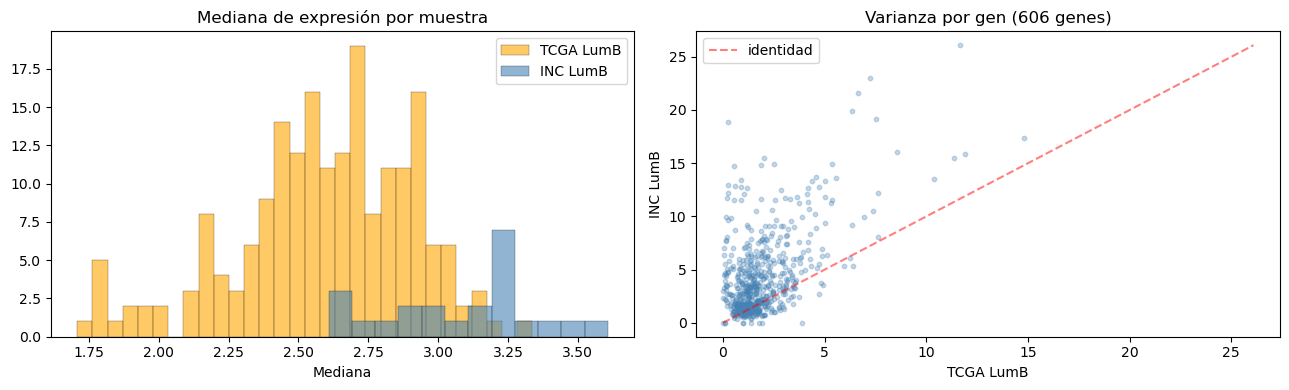

INC — media: 2.835 | mediana: 3.082 | std: 3.469 | rango: [-5.95, 13.87]
Orden LabelEncoder (XGBoost): [np.int64(0), np.int64(1), np.int64(2)]

===== Sensibilidad para Luminal B — Cohorte INC =====
                     LumB correctas  Total  Sensibilidad LumB
Modelo                                                       
KNN                              15     23              0.652
Random Forest                    12     23              0.522
Logistic Regression              18     23              0.783
XGBoost                          16     23              0.696
SVM                              19     23              0.826


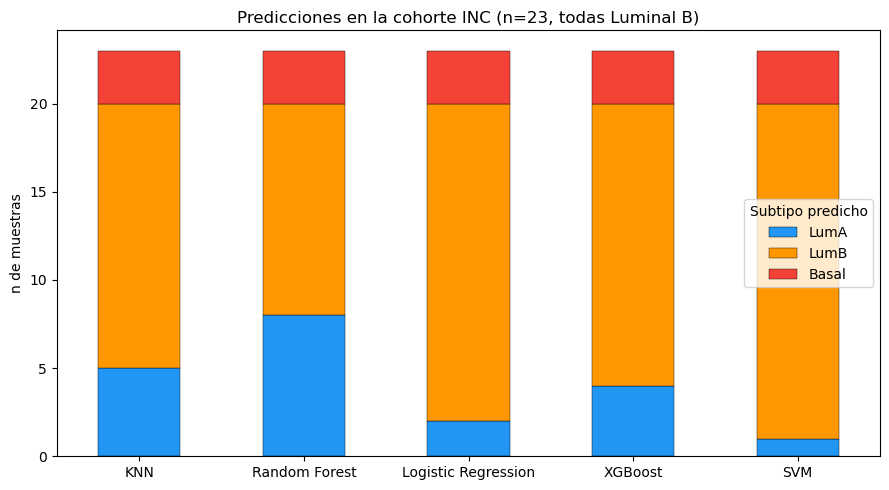

In [66]:
# ## Validación externa — Cohorte INC Bogotá (GSE309004)
# 23 muestras Luminal B con imagen pareada. Al ser una sola clase, la métrica
# interpretable es la **sensibilidad para Luminal B** (fracción correctamente
# clasificada); accuracy/F1 multiclase no aplican con una única clase presente.

# ── Bloque 0 · Carga y alineación al espacio de genes del modelo ──────────────
# Cargar con separador correcto
# ── Bloque 0 · Carga, reestructura y alineación (versión única) ──────────────
raw = pd.read_csv("filtered_normalized_data_INC_23.csv", sep=";", encoding="utf-8-sig")
raw = raw.rename(columns={raw.columns[0]: "rowlabel"}).set_index("rowlabel")
print("Índice (primeras filas):", raw.index[:4].tolist())

# Metadatos por POSICIÓN: fila 0 = Response (muestras), fila 1 = slide_ID; genes desde la fila 2
sample_names = raw.iloc[0].values
genes_inc    = raw.iloc[2:].copy()
genes_inc.columns = sample_names

df_inc = genes_inc.T.apply(pd.to_numeric, errors="coerce")
print("Shape df_inc (muestras x genes):", df_inc.shape)
print("Primeros genes:", df_inc.columns[:3].tolist())

# Alinear al espacio de genes del modelo -> crea X_inc
genes_modelo    = X_train.columns.tolist()
genes_faltantes = [g for g in genes_modelo if g not in df_inc.columns]
X_inc      = df_inc.reindex(columns=genes_modelo, fill_value=0).copy()
y_inc_true = np.ones(len(X_inc), dtype=int)

print(f"\nMuestras INC: {len(X_inc)} | Genes alineados: {X_inc.shape[1]}")
print(f"Genes faltantes ({len(genes_faltantes)}): {genes_faltantes}")


# ### 1 · Exploración de los datos INC
# Antes de validar se verifica que las distribuciones de expresión de INC sean
# comparables con las de TCGA. NOTA: INC está normalizado con VST y TCGA con
# log2(FPKM+1); esta diferencia de escala se documenta y se tiene en cuenta al
# interpretar los resultados.

# ── 1.1 · Distribución global de expresión (INC) ─────────────────────────────
vals = X_inc.values.flatten()
vals = vals[~np.isnan(vals)]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(vals, bins=50, color="steelblue", edgecolor="black", linewidth=0.3)
ax[0].set_title("Distribución global — INC"); ax[0].set_xlabel("Expresión (VST)"); ax[0].set_ylabel("Frecuencia")

kde = stats.gaussian_kde(vals)
xr  = np.linspace(vals.min(), vals.max(), 300)
ax[1].fill_between(xr, kde(xr), alpha=0.3, color="steelblue")
ax[1].plot(xr, kde(xr), color="steelblue", lw=2)
ax[1].set_title("Densidad — INC"); ax[1].set_xlabel("Expresión (VST)"); ax[1].set_ylabel("Densidad")
plt.tight_layout(); plt.show()


# ── 1.2 · Comparabilidad INC vs TCGA (solo Luminal B) ────────────────────────
X_lumb_tcga = (df_samples.loc[df_samples["Subtype"] == "LumB", genes_modelo]
               .apply(pd.to_numeric, errors="coerce"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# Medianas por muestra
ax[0].hist(X_lumb_tcga.median(axis=1), bins=30, alpha=0.6, color="orange",
           label="TCGA LumB", edgecolor="black", linewidth=0.3)
ax[0].hist(X_inc.median(axis=1), bins=12, alpha=0.6, color="steelblue",
           label="INC LumB", edgecolor="black", linewidth=0.3)
ax[0].set_title("Mediana de expresión por muestra"); ax[0].set_xlabel("Mediana"); ax[0].legend()

# Varianza por gen
vt, vi = X_lumb_tcga.var(axis=0), X_inc.var(axis=0)
mx = max(vt.max(), vi.max())
ax[1].scatter(vt, vi, alpha=0.3, s=10, color="steelblue")
ax[1].plot([0, mx], [0, mx], "r--", alpha=0.5, label="identidad")
ax[1].set_title("Varianza por gen (606 genes)"); ax[1].set_xlabel("TCGA LumB"); ax[1].set_ylabel("INC LumB"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"INC — media: {X_inc.values.mean():.3f} | mediana: {np.median(vals):.3f} | "
      f"std: {X_inc.values.std():.3f} | rango: [{X_inc.values.min():.2f}, {X_inc.values.max():.2f}]")

# ### 2 · Validación: sensibilidad para Luminal B
# Cada modelo predice el subtipo de las 23 muestras; se reporta cuántas clasifica
# correctamente como Luminal B. Las predicciones se decodifican a texto con el
# decodificador propio de cada modelo (XGBoost usa LabelEncoder; el resto, el
# mapeo manual) para evitar errores por el distinto orden de codificación.


# ### 2 · Validación: sensibilidad para Luminal B
# Cada modelo predice el subtipo de las 23 muestras; se reporta cuántas clasifica
# correctamente como Luminal B. Las predicciones se decodifican a texto con el
# decodificador propio de cada modelo (XGBoost usa LabelEncoder; el resto, el
# mapeo manual) para evitar errores por el distinto orden de codificación.

label_map = {0: "LumA", 1: "LumB", 2: "Basal"}
print("Orden LabelEncoder (XGBoost):", list(le.classes_))   # verificación del orden

modelos = {"KNN": knn_best, "Random Forest": best_rf, "Logistic Regression": best_log_reg_model,
           "XGBoost": best_xgb, "SVM": best_svm_model}

def a_texto(nombre, pred):
    pred = np.asarray(pred)
    # Si ya viene como texto, usarlo tal cual
    if pred.dtype.kind in ("U", "S", "O"):
        return pred.astype(str)
    # Todos los modelos devuelven 0/1/2 con el mismo mapeo
    return np.array([label_map[int(p)] for p in pred])

preds_txt, filas = {}, []
for nombre, modelo in modelos.items():
    txt = a_texto(nombre, modelo.predict(X_inc)).astype(str)
    preds_txt[nombre] = txt
    n_ok = int((txt == "LumB").sum())
    filas.append({"Modelo": nombre, "LumB correctas": n_ok,
                  "Total": len(txt), "Sensibilidad LumB": round(n_ok / len(txt), 3)})

tabla = pd.DataFrame(filas).set_index("Modelo")
print("\n===== Sensibilidad para Luminal B — Cohorte INC =====")
print(tabla.to_string())

# ── 2.1 · Distribución de predicciones por modelo ────────────────────────────
# A qué subtipos van a parar las 23 muestras (todas son LumB): idealmente todas
# a LumB; las que caen en LumA/Basal son los errores de cada modelo.
dist = (pd.DataFrame({n: pd.Series(t).value_counts() for n, t in preds_txt.items()})
        .T.reindex(columns=["LumA", "LumB", "Basal"], fill_value=0).fillna(0).astype(int))

ax = dist.plot(kind="bar", stacked=True, figsize=(9, 5),
               color=["#2196F3", "#FF9800", "#F44336"], edgecolor="black", linewidth=0.3)
ax.set_title(f"Predicciones en la cohorte INC (n={len(X_inc)}, todas Luminal B)")
ax.set_ylabel("n de muestras"); ax.set_xlabel(""); ax.legend(title="Subtipo predicho")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [67]:
# Comparar la codificación real contra el mapeo asumido
print(df_samples[['Subtype', 'Subtype_Encoded']].drop_duplicates().sort_values('Subtype_Encoded'))

Subtipo Subtype  Subtype_Encoded
0          LumA                0
191        LumB                1
386       Basal                2



### **5. Análisis no supervisado**

Exploración de la estructura de los datos sin usar las etiquetas de subtipo, mediante reducción de dimensionalidad (PCA, UMAP) y agrupamiento (K-Means, jerárquico). Cada método de agrupamiento se evalúa con dos métricas comparables: el **coeficiente de silueta** (cohesión/separación interna de los clústeres) y el **Adjusted Rand Index (ARI)** frente a los subtipos reales (concordancia externa).

#### **5. Preparación**

In [17]:
# Matriz numérica (pacientes x genes) y etiquetas verdaderas
X_num = X.apply(pd.to_numeric, errors='coerce')
X_num = X_num.fillna(X_num.mean())

labels_true = df_samples['Subtype'].values          # subtipo (texto)
y_true      = df_samples['Subtype_Encoded'].values  # subtipo codificado (0,1,2)

# Estandarizacion (media 0, var 1): requerida para PCA / clustering / UMAP
X_scaled = StandardScaler().fit_transform(X_num)

COLOR_MAP = {'LumA': '#2196F3', 'LumB': '#FF9800', 'Basal': '#F44336'}
print(f'Matriz: {X_scaled.shape[0]} pacientes x {X_scaled.shape[1]} genes')

Matriz: 552 pacientes x 604 genes


#### **5.1 PCA — Análisis de Componentes Principales**

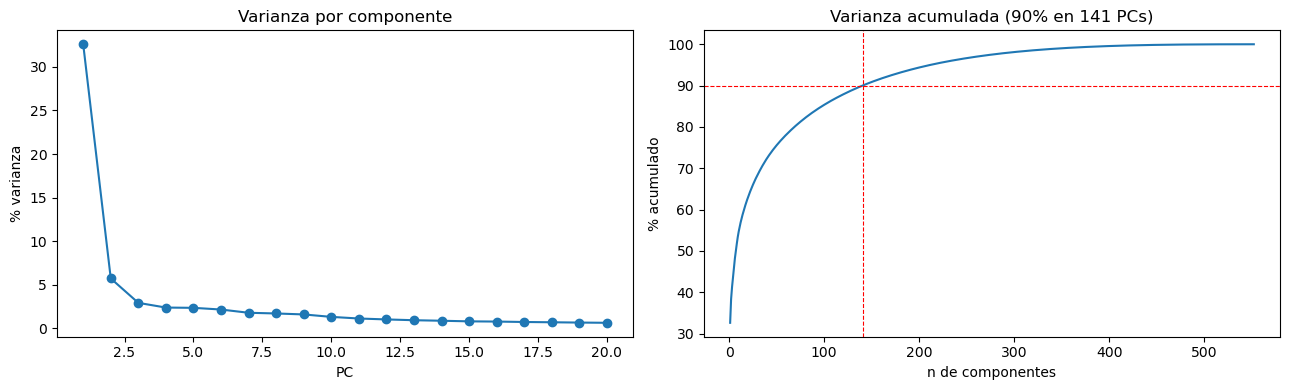

PC1: 32.59%  |  PC2: 5.73%  |  90% con 141 componentes


In [18]:
# Varianza explicada por componente y acumulada
pca_full  = PCA(random_state=42).fit(X_scaled)
var_ratio = pca_full.explained_variance_ratio_
cum_var   = var_ratio.cumsum()
n_90 = int(np.argmax(cum_var >= 0.90) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1, 21), var_ratio[:20]*100, 'o-')
ax[0].set_title('Varianza por componente'); ax[0].set_xlabel('PC'); ax[0].set_ylabel('% varianza')
ax[1].plot(range(1, len(cum_var)+1), cum_var*100, '-')
ax[1].axhline(90, color='r', ls='--', lw=0.8); ax[1].axvline(n_90, color='r', ls='--', lw=0.8)
ax[1].set_title(f'Varianza acumulada (90% en {n_90} PCs)')
ax[1].set_xlabel('n de componentes'); ax[1].set_ylabel('% acumulado')
plt.tight_layout(); plt.show()

print(f'PC1: {var_ratio[0]*100:.2f}%  |  PC2: {var_ratio[1]*100:.2f}%  |  90% con {n_90} componentes')

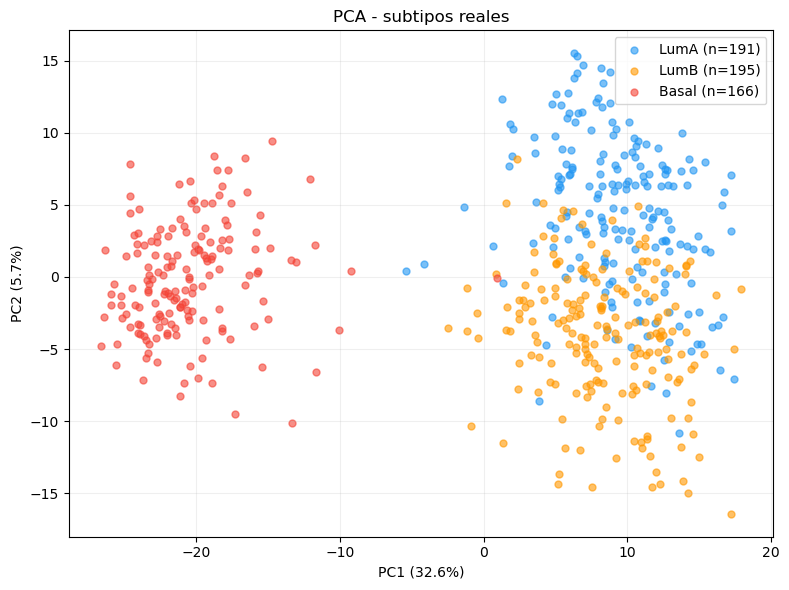

In [19]:
# Proyeccion 2D coloreada por subtipo real
pca2  = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
v = pca2.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
for sub, c in COLOR_MAP.items():
    m = labels_true == sub
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=c, label=f'{sub} (n={m.sum()})', alpha=0.6, s=25)
plt.xlabel(f'PC1 ({v[0]:.1f}%)'); plt.ylabel(f'PC2 ({v[1]:.1f}%)')
plt.title('PCA - subtipos reales'); plt.legend(); plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [20]:
# Genes con mayor carga (loadings) en PC1: insumo para enriquecimiento (DAVID)
loadings = pd.DataFrame(pca_full.components_[:2].T, index=X_num.columns, columns=['PC1','PC2'])
top_pc1_pos = loadings['PC1'].sort_values(ascending=False).head(10)
top_pc1_neg = loadings['PC1'].sort_values().head(10)
print('Top 10 PC1 (+):'); print(top_pc1_pos)
print('\nTop 10 PC1 (-):'); print(top_pc1_neg)
top_pc1_pos.rename('PC1_loading').to_csv('top10_pc1_positive_genes.csv')

Top 10 PC1 (+):
Subtipo
FOXA1     0.068074
MLPH      0.066180
ESR1      0.065540
AGR3      0.064363
TBC1D9    0.064286
XBP1      0.064253
THSD4     0.062943
CA12      0.062692
GATA3     0.062430
AGR2      0.062275
Name: PC1, dtype: float64

Top 10 PC1 (-):
Subtipo
FOXC1      -0.063598
PPP1R14C   -0.061375
PSAT1      -0.060555
VGLL1      -0.058718
FAM171A1   -0.058693
GABRP      -0.058540
HAPLN3     -0.058444
KRT16      -0.058042
EN1        -0.056762
UGT8       -0.056690
Name: PC1, dtype: float64


#### **5.2 K-Means**

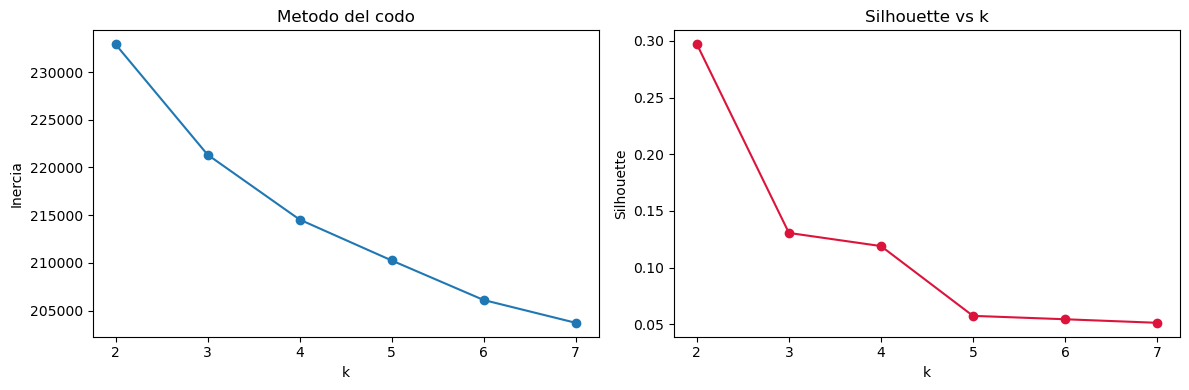

In [21]:
# Seleccion de k: metodo del codo (inercia) + silueta
K_range = range(2, 8)
inertias, sil = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertias, 'o-'); ax[0].set_title('Metodo del codo'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia')
ax[1].plot(K_range, sil, 'o-', color='crimson'); ax[1].set_title('Silhouette vs k'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

# Ajuste final con k=3 (3 subtipos)
km_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)

#### **5.3 Clustering jerárquico**

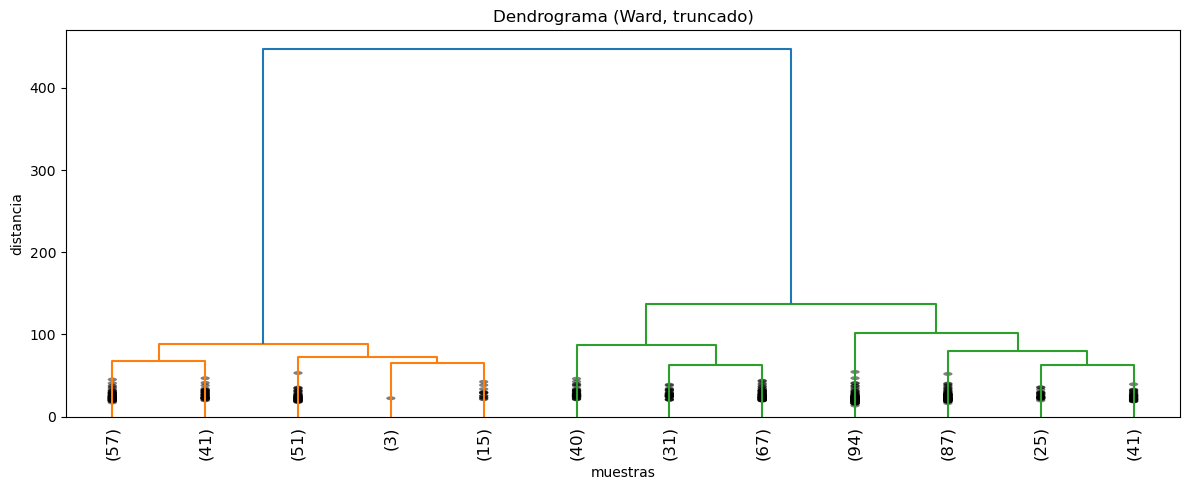

In [22]:
# Enlace de Ward + dendrograma truncado
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=12, leaf_rotation=90., show_contracted=True)
plt.title('Dendrograma (Ward, truncado)'); plt.xlabel('muestras'); plt.ylabel('distancia')
plt.tight_layout(); plt.show()

# Corte en 3 clusteres
hc_labels = fcluster(Z, 3, criterion='maxclust')

#### **5.4 UMAP**

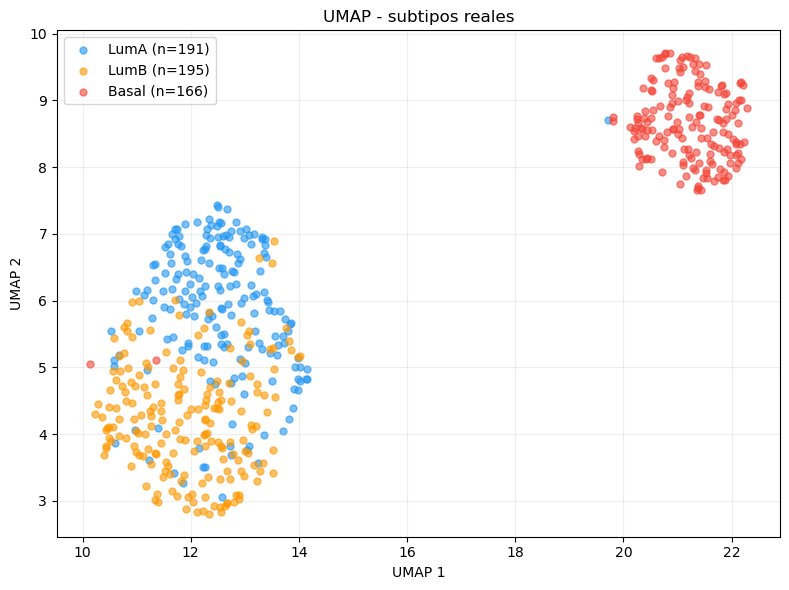

In [68]:
# UMAP 2D sobre los datos estandarizados
reducer   = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for sub, c in COLOR_MAP.items():
    m = labels_true == sub
    plt.scatter(embedding[m, 0], embedding[m, 1], c=c, label=f'{sub} (n={m.sum()})', alpha=0.6, s=25)
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2'); plt.title('UMAP - subtipos reales')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

# Clustering en el espacio UMAP (para metricas comparables)
umap_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(embedding)

#### **5.5 Métricas comparables**

In [69]:
# Silueta (interna) y ARI vs subtipos reales (externa) para cada agrupamiento
def evaluar(nombre, labels):
    return {'Metodo': nombre,
            'Silhouette': round(silhouette_score(X_scaled, labels), 3),
            'ARI_vs_subtipo': round(adjusted_rand_score(y_true, labels), 3)}

metricas = pd.DataFrame([
    evaluar('K-Means',           km_labels),
    evaluar('Jerarquico (Ward)', hc_labels),
    evaluar('UMAP + K-Means',    umap_labels),
]).set_index('Metodo')
print(metricas)
print(f'\nPCA  - PC1+PC2 explican {var_ratio[0]*100 + var_ratio[1]*100:.1f}% de la varianza')
print('UMAP - proyeccion 2D (n_neighbors=30, min_dist=0.1)')

                   Silhouette  ARI_vs_subtipo
Metodo                                       
K-Means                 0.131           0.640
Jerarquico (Ward)       0.130           0.501
UMAP + K-Means          0.129           0.700

PCA  - PC1+PC2 explican 38.3% de la varianza
UMAP - proyeccion 2D (n_neighbors=30, min_dist=0.1)


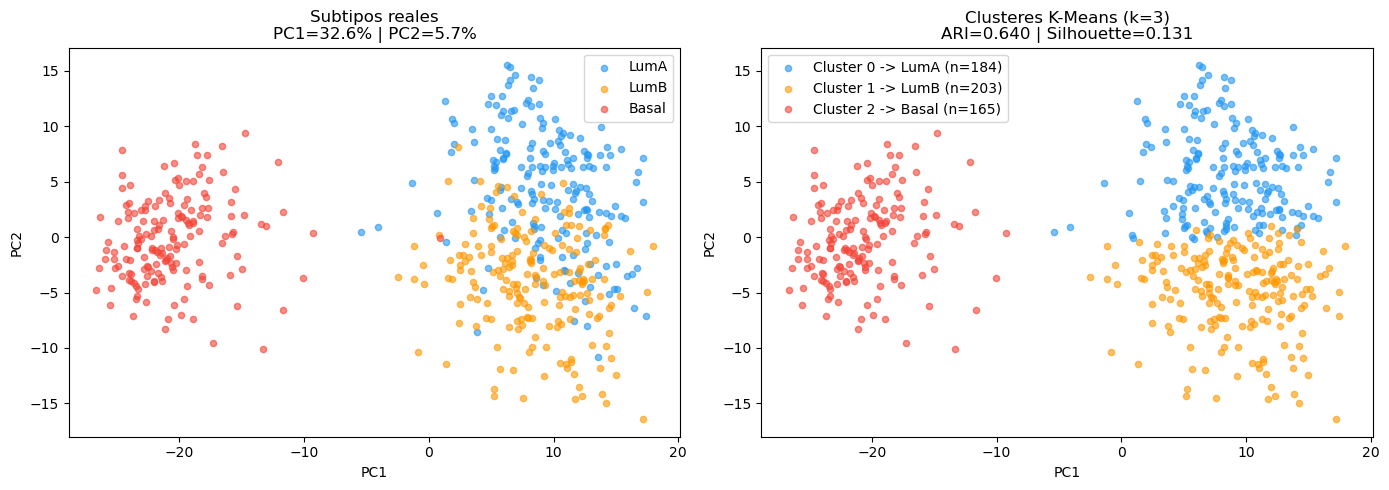

In [70]:
# Panel comparativo: subtipos reales vs clusteres K-Means (mapeados al subtipo mayoritario)
cluster_map = (pd.DataFrame({'k': km_labels, 'sub': labels_true})
               .groupby('k')['sub'].agg(lambda s: s.value_counts().index[0]).to_dict())
ari_km = adjusted_rand_score(y_true, km_labels)
sil_km = silhouette_score(X_scaled, km_labels)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for sub, c in COLOR_MAP.items():
    m = labels_true == sub
    ax[0].scatter(X_pca[m,0], X_pca[m,1], c=c, label=sub, alpha=0.6, s=20)
ax[0].set_title(f'Subtipos reales\nPC1={v[0]:.1f}% | PC2={v[1]:.1f}%'); ax[0].legend()
for k in range(3):
    m = km_labels == k
    ax[1].scatter(X_pca[m,0], X_pca[m,1], c=COLOR_MAP[cluster_map[k]],
                  label=f'Cluster {k} -> {cluster_map[k]} (n={m.sum()})', alpha=0.6, s=20)
ax[1].set_title(f'Clusteres K-Means (k=3)\nARI={ari_km:.3f} | Silhouette={sil_km:.3f}'); ax[1].legend()
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()